       LAB 05: NETWORK PACKET DELIVERY (BINOMIAL DISTRIBUTION)
Number of Packets in a Batch (n) : 15
Success Probability (p)          : 0.9
Failure Probability (q)          : 0.10
-----------------------------------------------------------------
Probability that exactly 13 packets arrive safely: 0.266896 (26.69%)
-----------------------------------------------------------------
Theoretical Mean (μ)             : 13.5000
Theoretical Variance (σ²)        : 1.3500
-----------------------------------------------------------------
--- DATA VERIFICATION ---
Simulation Example Data (5 batches): [14, 13, 15, 12, 14]
Calculated Sample Average          : 13.6000
Theoretical Mean (μ)               : 13.5000
Difference (Theoretical - Sample)  : 0.1000


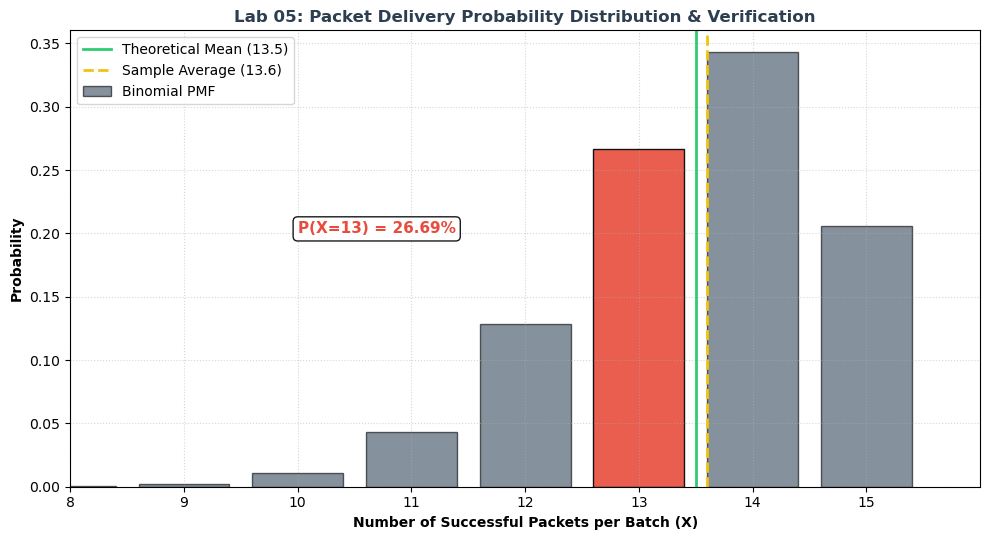

In [3]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

# =========================================================================
# Task 1: Identify Parameters
# =========================================================================
n = 15       # Total number of independent packets in a batch
p = 0.90     # Success probability of an individual packet
q = 1 - p    # Failure probability

print("=" * 65)
print("       LAB 05: NETWORK PACKET DELIVERY (BINOMIAL DISTRIBUTION)")
print("=" * 65)
print(f"Number of Packets in a Batch (n) : {n}")
print(f"Success Probability (p)          : {p}")
print(f"Failure Probability (q)          : {q:.2f}")
print("-" * 65)

# =========================================================================
# Task 2: Exact Probability (X = 13)
# =========================================================================
# সূত্র: P(X=k) = nCk * p^k * q^(n-k)
x_target = 13
exact_prob = stats.binom.pmf(x_target, n, p)
print(f"Probability that exactly {x_target} packets arrive safely: {exact_prob:.6f} ({exact_prob*100:.2f}%)")
print("-" * 65)

# =========================================================================
# Task 3: Expected Value & Variance
# =========================================================================
# সূত্র: Mean = n * p , Variance = n * p * q
theoretical_mean = n * p
theoretical_variance = n * p * q

print(f"Theoretical Mean (μ)             : {theoretical_mean:.4f}")
print(f"Theoretical Variance (σ²)        : {theoretical_variance:.4f}")
print("-" * 65)

# =========================================================================
# Task 4: Data Verification with Example Data
# =========================================================================
example_data = [14, 13, 15, 12, 14]
sample_average = np.mean(example_data)

print("--- DATA VERIFICATION ---")
print(f"Simulation Example Data (5 batches): {example_data}")
print(f"Calculated Sample Average          : {sample_average:.4f}")
print(f"Theoretical Mean (μ)               : {theoretical_mean:.4f}")
print(f"Difference (Theoretical - Sample)  : {abs(theoretical_mean - sample_average):.4f}")
print("=" * 65)

# =========================================================================
# Visualizing the Binomial Distribution PMF & Simulation Data
# =========================================================================
all_x = np.arange(0, n + 1)
all_pmf = stats.binom.pmf(all_x, n, p)

plt.figure(figsize=(10, 5.5))

# সম্পূর্ণ বাইনমিয়াল ডিস্ট্রিবিউশন বার প্লট
bars = plt.bar(all_x, all_pmf, color='#34495e', alpha=0.6, edgecolor='black', label='Binomial PMF')

# ম্যাজিক হাইলাইট: ঠিক ১৩ নম্বর বারটি আলাদা রঙে দেখানো
bars[x_target].set_color('#e74c3c')
bars[x_target].set_edgecolor('black')
bars[x_target].set_alpha(0.9)

# থিওরিটিক্যাল মিন এবং স্যাম্পল অ্যাভারেজ গ্রাফে ভার্টিকাল লাইন দিয়ে দেখানো
plt.axvline(x=theoretical_mean, color='#2ecc71', linestyle='-', linewidth=2, label=f'Theoretical Mean ({theoretical_mean})')
plt.axvline(x=sample_average, color='#f1c40f', linestyle='--', linewidth=2, label=f'Sample Average ({sample_average})')

# ১৩টি প্যাকেটের স্পেশাল টেক্সট বক্স
plt.text(10, 0.20, f"P(X=13) = {exact_prob*100:.2f}%", color='#e74c3c', fontsize=11, fontweight='bold',
         bbox=dict(facecolor='white', alpha=0.9, boxstyle='round,pad=0.3'))

# গ্রাফ সুন্দর করার প্রফেশনাল সেটআপ
plt.title("Lab 05: Packet Delivery Probability Distribution & Verification", fontsize=12, fontweight='bold', color='#2c3e50')
plt.xlabel("Number of Successful Packets per Batch (X)", fontsize=10, fontweight='bold')
plt.ylabel("Probability", fontsize=10, fontweight='bold')
plt.xlim(8, 16) # যেহেতু p=0.90, ডেটা মূলত ৮ থেকে ১৫ এর মধ্যে থাকবে
plt.xticks(np.arange(8, 16))
plt.grid(True, linestyle=":", alpha=0.5)
plt.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()